# Análisis Exploratorio del Dataset de Popularidad de Canciones en Spotify

Este notebook explora el dataset de canciones de Spotify, compuesto por características de audio y la popularidad de cada tema. Identificaremos patrones, calidad de los datos y prepararemos la información para su posterior análisis y modelamiento, adaptado al contexto del proyecto.

## Configuración del Entorno y la Carga de Datos

Para garantizar la consistencia de este análisis, configuramos el entorno de trabajo para que sea dinámico. El código detecta automáticamente si se está ejecutando en la nube (Google Colab) o en un entorno local (Visual Studio Code), ajustando las rutas de los archivos.

**Primera validación de datos:** cargamos el dataset (`data/raw/spotify_tracks.csv`) aplicando una limpieza inicial con el parámetro `na_values`, para asegurar que strings vacíos o textos como "NULL"/"N/A" sean interpretados correctamente por Pandas como valores faltantes (`NaN`).

In [2]:
# Se importan las librerías necesarias para el análisis de datos y visualización
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Se ocultan advertencias para mantener el notebook limpio
warnings.filterwarnings('ignore') # Aveces aparecen advertencias molestas, que realmente no afectan al dataset

# Se configura la visualización para que se vea más profesional
sns.set_context("talk") # Eso escala automatiamente el de los elementos para las presentaciones
sns.set_theme(
    style="whitegrid",
    rc={
        "axes.titlesize": 18, # Los titulos de los ejes se verán más grandes
        "axes.labelsize": 14, # Las etiquetas de los ejes se verán más grandes
        "xtick.labelsize": 12, # Esto enumera el tamaño de las etiquetas
        "ytick.labelsize": 12,
    },
)
plt.rcParams['figure.figsize'] = (10, 6) # Con esto se ajusta el tamaño de los gráficos

In [ ]:
# Detectar si estamos en Google Colab y ajustar la ruta del archivo
try:
    import google.colab
    IN_COLAB = True # Si funciona, estamos en la nube (colab)
except ImportError:
    IN_COLAB = False # Si falla, estamos en local (VSC)

# Se configura la ruta del archivo dependiendo del entorno
if IN_COLAB:
    print('Google Colab detectado. Sube el archivo.')
    from google.colab import files
    uploaded = files.upload() # Esto abre una ventana para seleccionar múltiples archivos
    if not uploaded:
        # Si se cancela la subida, se lanza un error
        raise FileNotFoundError('Debe subir el archivo a Colab antes de ejecutar el notebook.')
    ruta_base = '' # En Colab los archivos quedan en la raíz temporal
else:
    # Si no estamos en Colab, se asume que los archivos están en la ruta local
    ruta_base = '../data/raw/'

print("Iniciando la carga de los datos...")

# IMPORTANTE: verifiquen el nombre exacto del archivo descargado desde Kaggle
# (en algunos casos el CSV se llama 'dataset.csv')
ruta_archivo = os.path.join(ruta_base, 'dataset.csv')

df_final = pd.read_csv(
    ruta_archivo,
    na_values=['', 'NULL', 'null', 'N/A', 'NaN']
)

# Se hace una inspección rápida del dataset para entender su estructura
print(f"-> Canciones cargadas: {df_final.shape[0]} filas.")
print(f"Dimensiones del dataset final (df_final): {df_final.shape}") # Esto muestra cuantas filas y columnas tiene el dataset
df_final.head() # Esto muestra las primeras 5 filas del dataset para tener una idea de su contenido

Iniciando la carga de los datos...
-> Canciones cargadas: 114000 filas.
Dimensiones del dataset final (df_final): (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [12]:
# Cuenta cuántas canciones hay por cada género musical
df_final['track_genre'].value_counts()

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64

## Diccionario de variables clave

| Variable | Descripción |
|---|---|
| `track_id` | Identificador único de la canción en Spotify |
| `artists` | Artista(s) de la canción |
| `album_name` | Nombre del álbum |
| `track_name` | Nombre de la canción |
| `popularity` | Puntaje de popularidad (0-100), **variable objetivo** |
| `duration_ms` | Duración de la canción en milisegundos |
| `explicit` | Si la canción tiene contenido explícito (True/False) |
| `danceability` | Qué tan "bailable" es la canción (0.0-1.0) |
| `energy` | Intensidad y actividad percibida (0.0-1.0) |
| `key` | Tonalidad musical (0-11, notación de clases de tono) |
| `loudness` | Volumen general en decibeles (dB) |
| `mode` | Modalidad (1 = mayor, 0 = menor) |
| `speechiness` | Presencia de palabras habladas (0.0-1.0) |
| `acousticness` | Confianza de que la canción es acústica (0.0-1.0) |
| `instrumentalness` | Predicción de ausencia de voz (0.0-1.0) |
| `liveness` | Detección de presencia de audiencia en vivo (0.0-1.0) |
| `valence` | Positividad musical transmitida (0.0-1.0) |
| `tempo` | Tempo estimado en BPM |
| `time_signature` | Compás estimado |
| `track_genre` | Género musical de la canción |


### Inspección de datos:

Al analizar el resultado de `info()`, descubrimos aspectos importantes sobre la calidad de los datos que guiarán nuestro preprocesamiento:

1. **Nulos mínimos, pero no cero:** Las variables `artists`, `album_name` y `track_name` presentan **114.000 vs 113.999** registros no nulos, es decir, solo **1 fila con valores faltantes**. A diferencia de datasets con perfiles de usuario incompletos, aquí el volumen de nulos es prácticamente insignificante, por lo que la estrategia más simple y razonable es eliminarla directamente, sin necesidad de imputación.

2. **Tipos de datos ya correctos y bien definidos:** A diferencia de catálogos menos estructurados, este dataset viene con los tipos de datos ya optimizados desde su origen: `explicit` ya es de tipo `bool`, y las variables de audio (`danceability`, `energy`, `valence`, etc.) ya están en `float` listas para el análisis. Sin embargo, variables como `key`, `mode` y `time_signature` son en realidad **categóricas codificadas como números** (ej. `mode` solo toma valores 0 o 1), por lo que deberemos evaluar si tratarlas como numéricas o convertirlas a categóricas antes de modelar.

3. **Variables identificatorias sin valor predictivo directo:** Columnas como `track_id`, `track_name`, `album_name` y `artists` son de tipo texto (`str`), pero a diferencia de un campo como una reseña de usuario, no contienen información desestructurada que requiera NLP para este análisis, ya que son principalmente identificadores. Su utilidad está en saber qué canción es cada fila, no como input directo del modelo, por lo que deberán excluirse al momento de construir el set de entrenamiento.

4. **Volumen de datos manejable:** Con 114.000 registros y un uso de memoria de solo 26.8 MB, el dataset es liviano y no representa un desafío de rendimiento como sí lo sería un dataset de un millón de filas. El principal riesgo de volumen no está en el tamaño del dataset en sí, sino en la **codificación de `track_genre`** (114 categorías distintas): aplicar one-hot encoding sobre esta variable generará más de 100 columnas nuevas, lo que deberemos considerar al preparar los datos para el modelamiento.

In [14]:
# Información general del dataset
print('Información del dataset:')
df_final.info() # Nos muestra el tipo de datos de cada columna y cuántos valores no nulos que tiene

print("\n" + "="*50 + "\n") # Esto es solo para separar visualmente las secciones del notebook

print('\nResumen estadístico de variables numéricas:')
df_final.describe(include='all').T # Esto nos genera estadísticas descriptivas para todas las variables

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  livene

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,NaN,NaN,NaN,56999.5,32909.109681,0.0,28499.75,56999.5,85499.25,113999.0
track_id,114000,89741,6S3JlDAGk3uu3NtZbPnuhS,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artists,113999,31437,The Beatles,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_name,113999,46589,Alternative Christmas 2022,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,113999,73608,Run Rudolph Run,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,114000.0,NaN,NaN,NaN,33.238535,22.305078,0.0,17.0,35.0,50.0,100.0
duration_ms,114000.0,NaN,NaN,NaN,228029.153114,107297.712645,0.0,174066.0,212906.0,261506.0,5237295.0
explicit,114000,2,False,104253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,114000.0,NaN,NaN,NaN,0.5668,0.173542,0.0,0.456,0.58,0.695,0.985
energy,114000.0,NaN,NaN,NaN,0.641383,0.251529,0.0,0.472,0.685,0.854,1.0


### Limpieza Estructural y Detección de Valores Nulos

Antes de proceder con el análisis exploratorio, realizaremos una limpieza estructural básica sobre el dataset:

1. **Eliminación de columnas irrelevantes:** Descartaremos la columna `Unnamed: 0`, un índice residual que no aporta valor predictivo ni analítico.
2. **Eliminación de registros corruptos:** Se identificó un registro (índice 65900) sin metadata (`artists`, `album_name`, `track_name` nulos) y con `duration_ms = 0`, lo que indica una fila corrupta y no una canción real. Este registro será eliminado.
3. **Cuantificación de datos faltantes:** Calcularemos el volumen de valores nulos restantes en el dataset, para confirmar que la limpieza fue efectiva antes de continuar con el análisis.

In [21]:
# Se eliminan las columnas que son innecesarias

# Se define en una lista el nombre a eliminar
columnas_a_eliminar = ['Unnamed: 0'] # Unnamed: 0 -> Suele aparecer como basura
# Se ocupa un filtro de seguridad que revisa que realmente existe la fila antes de eliminarla
columnas_a_eliminar = [c for c in columnas_a_eliminar if c in df_final.columns] # Además evita que el programa tire un error si la fila no existe
df_final = df_final.drop(columns=columnas_a_eliminar)

# Se eliminan las filas que son innecesarias

# Se elimina la fila específica con el índice 65900
df_final = df_final.drop(index=65900, errors='ignore').reset_index(drop=True) 

# Se calculan los valores faltantes

nulos = df_final.isnull().sum() # .isnull() -> evalúa cada celda para ver si está vacía
# Se calcula el porcentaje de nulos y con len(df_final) obtenemos el total de filas del dataset
porcentaje_nulos = (nulos / len(df_final)) * 100
# Se crea un nuevo DataFrame
resumen_nulos = pd.DataFrame({
    'nulos': nulos,
    'porcentaje': porcentaje_nulos.round(2)
}).sort_values('porcentaje', ascending=False) # .sort_values() ordena la tabla, poniendo arriba las columnas con más nulos

# Se visualiza el resultado

resumen_nulos[resumen_nulos['nulos'] > 0]

,nulos,porcentaje


### Análisis de duplicados
Se evalúa si existen filas duplicadas usando `.duplicated().sum()`.

In [22]:
# Se muestra el número de filas duplicadas (exactas) en el dataset final
duplicados = df_final.duplicated().sum()
print(f"Número de filas duplicadas: {duplicados}")

# También revisar duplicados por track_id, ya que una canción
# puede repetirse en distintos géneros del dataset
if 'track_id' in df_final.columns:
    duplicados_por_id = df_final.duplicated(subset=['track_id']).sum()
    print(f"Número de track_id duplicados: {duplicados_por_id}")

    pct_dup_id = (duplicados_por_id / len(df_final)) * 100
    print(f"Porcentaje de track_id duplicados: {pct_dup_id:.2f}%")

# Porcentaje de duplicados exactos sobre el total
pct_dup = (duplicados / len(df_final)) * 100
print(f"Porcentaje de filas exactamente duplicadas: {pct_dup:.4f}%")

Número de filas duplicadas: 450
Número de track_id duplicados: 24259
Porcentaje de track_id duplicados: 21.28%
Porcentaje de filas exactamente duplicadas: 0.3947%


### Conclusiones del Análisis

El análisis de valores faltantes y registros duplicados permitió identificar aspectos relevantes que deberán considerarse en las etapas posteriores de preprocesamiento.

1. **Ausencia de valores nulos tras la limpieza estructural:** A diferencia de datasets con perfiles de usuario incompletos, este dataset presentó un único registro corrupto (índice 65900, sin metadata y con `duration_ms = 0`), el cual ya fue eliminado. Tras esta limpieza, el dataset no presenta valores nulos en ninguna columna.

2. **Duplicados por `track_id` (21.28%) — no representan un error:** Se identificaron 24.259 registros con `track_id` repetido. Al investigar la causa, se confirmó que corresponden a canciones catalogadas legítimamente en múltiples géneros musicales (hasta 9 géneros distintos para una misma canción), y no a errores de carga. **No serán eliminados**, ya que representan información válida sobre la clasificación multi-género de Spotify.

3. **Aparición de duplicados exactos tras eliminar la columna de índice (450 filas, 0.39%):** Inicialmente no se detectaban duplicados exactos, ya que la columna `Unnamed: 0` (un índice secuencial) hacía que cada fila pareciera única. Al eliminar esta columna por no aportar valor analítico, se revelaron 450 filas verdaderamente idénticas en todo su contenido (mismo `track_id`, género y características de audio). A diferencia de los duplicados por multi-género, estos sí corresponden a registros redundantes sin información adicional, por lo que **serán eliminados** en la etapa de preparación de datos.

4. **Valores de `tempo = 0` concentrados en el género "sleep" (157 casos, 0.14%):** Se identificó que el 88% de estos casos corresponde a música ambiental/para dormir, donde el algoritmo de Spotify no logra detectar un pulso rítmico. No se tratan como error, sino como una característica genuina del género; se evaluará su imputación únicamente si `tempo` se utiliza como variable predictora en el modelamiento.

5. **Variable objetivo (`popularity`) sin valores faltantes:** A diferencia de datasets donde la variable objetivo presenta nulos que deben excluirse antes del entrenamiento, `popularity` no presenta ningún valor faltante en este dataset, por lo que no se requiere un tratamiento especial en este aspecto.

In [23]:
# Se eliminan los duplicados exactos detectados tras remover la columna de índice
df_final = df_final.drop_duplicates().reset_index(drop=True)
print(f"Filas después de eliminar duplicados exactos: {df_final.shape[0]}")

Filas después de eliminar duplicados exactos: 113549


Generando mapa de calor... (esto puede tomar unos segundos)


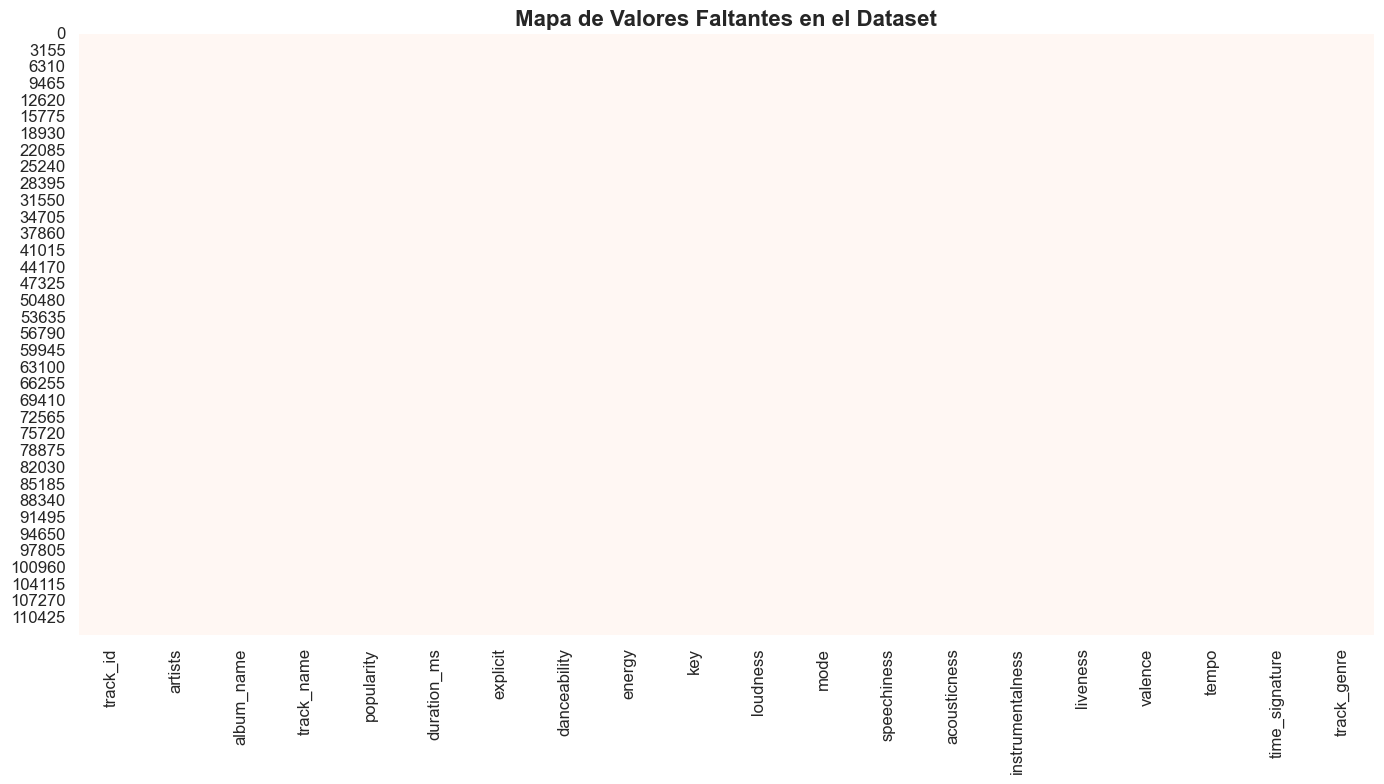

In [25]:
# Se genera un mapa de calor para visualizar la distribución de los valores faltantes en el dataset
print("Generando mapa de calor... (esto puede tomar unos segundos)")

plt.figure(figsize=(14, 8))
# Se visualizan los nulos
sns.heatmap(df_final.isnull(), cbar=False, cmap='RdPu')

plt.title("Mapa de Valores Faltantes en el Dataset", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

**Confirmación visual de la limpieza de nulos**

El mapa de calor confirma que, tras la eliminación del registro corrupto, el dataset no presenta valores faltantes en ninguna columna.

## Estadísticas descriptivas
Se muestran estadísticas:
- Numéricas y categóricas usando `.describe()`.
- Para categóricas se utiliza `include='object'`.

Esto da una vista general de rangos, frecuencias y posibles señales de limpieza requerida (por ejemplo, valores constantes, rangos extraños, etc.).

In [26]:
# Se muestra el número de columnas numéricas y categóricas (object) para entender la composición del dataset
num_cols = df_final.select_dtypes(include=np.number).columns.tolist()
cat_cols = df_final.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"Columnas numéricas ({len(num_cols)}): {num_cols}")
print(f"\nColumnas categóricas ({len(cat_cols)}): {cat_cols}")

print("\n--- describe() numéricas ---")
# Se muestra el resumen estadístico de las columnas numéricas para entender su distribución, media, mediana, etc.
display(df_final[num_cols].describe().T)

print("\n--- describe() categóricas (top/frecuencia) ---")
# Se muestra el resumen estadístico de las columnas categóricas para entender su distribución, valores más frecuentes, etc.
if len(cat_cols) > 0: # Si hay columnas categóricas, se muestra su descripción
    display(df_final[cat_cols].describe(include="object").T)
else: # Si no hay columnas categóricas, se muestra un mensaje indicando que no existen
    print("No hay columnas categóricas tipo 'object'.")

Columnas numéricas (14): ['popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']

Columnas categóricas (5): ['track_id', 'artists', 'album_name', 'track_name', 'track_genre']

--- describe() numéricas ---


,count,mean,std,min,25%,50%,75%,max
popularity,113549.0,33.324433,22.283855,0.000,17.0000,35.000000,50.0000,100.000
duration_ms,113549.0,228081.370844,106413.098525,8586.000,174184.0000,213000.000000,261588.0000,5237295.000
danceability,113549.0,0.567031,0.173409,0.000,0.4560,0.580000,0.6950,0.985
energy,113549.0,0.642091,0.251053,0.000,0.4730,0.685000,0.8540,1.000
key,113549.0,5.309452,3.560147,0.000,2.0000,5.000000,8.0000,11.000
loudness,113549.0,-8.243408,5.011422,-49.531,-9.9980,-6.997000,-5.0010,4.532
mode,113549.0,0.637866,0.480620,0.000,0.0000,1.000000,1.0000,1.000
speechiness,113549.0,0.084674,0.105762,0.000,0.0359,0.048900,0.0845,0.965
acousticness,113549.0,0.314064,0.331906,0.000,0.0168,0.168000,0.5960,0.996
instrumentalness,113549.0,0.155703,0.309217,0.000,0.0000,0.000041,0.0487,1.000



--- describe() categóricas (top/frecuencia) ---


,count,unique,top,freq
track_id,113549,89740,6S3JlDAGk3uu3NtZbPnuhS,9
artists,113549,31437,The Beatles,279
album_name,113549,46589,Alternative Christmas 2022,195
track_name,113549,73608,Run Rudolph Run,151
track_genre,113549,114,acoustic,1000


### Conclusiones de las Estadísticas Descriptivas

El análisis descriptivo permitió comprender mejor la estructura y comportamiento general de las variables presentes en el dataset.

**Variables numéricas**
1. **Variable objetivo con amplia dispersión:** La variable `popularity` presenta una media de 33.3 y una mediana de 35 (escala 0-100), con una desviación estándar de 22.3. Esto indica que la popularidad está bastante dispersa entre las canciones, sin una concentración fuerte en valores altos o bajos, lo cual es favorable para un futuro modelo de predicción.
2. **Predominio de tonalidad mayor:** La variable `mode` muestra una media de 0.64, lo que significa que aproximadamente el 64% de las canciones están compuestas en modo mayor, reflejando una tendencia natural de la música popular hacia tonalidades más "brillantes".
3. **Distribuciones asimétricas en variables de audio:** Variables como `speechiness`, `acousticness` e `instrumentalness` presentan medianas muy cercanas a 0 pero máximos cercanos a 1, sugiriendo distribuciones fuertemente sesgadas: la mayoría de las canciones tiene poca presencia de estos atributos, salvo un grupo reducido de casos extremos (ej. podcasts, música instrumental o acústica pura).
4. **Presencia de valores atípicos con explicación de dominio:** Se detectaron valores extremos en `duration_ms` (máximo de ~87 minutos, correspondiente a un mix de DJ del género minimal-techno), `tempo` y `time_signature` (163 y 157 casos en 0, concentrados en géneros ambientales como sleep y ambient), y `loudness` (90 casos con valores positivos, asociados al fenómeno de masterización conocido como "guerra del loudness"). A diferencia de errores de captura, estos casos responden mayoritariamente a características reales del dominio musical y se documentarán para su tratamiento en la etapa de preparación de datos.

**Variables categóricas**
1. **Alta cardinalidad en identificadores:** La variable `track_id` registra 89.740 valores únicos sobre 113.549 filas, y `track_name` alcanza 73.608 valores únicos. Esta diferencia se explica por la duplicidad de canciones en múltiples géneros, ya documentada en el análisis de duplicados.
2. **Concentración moderada en artistas:** La variable `artists` presenta 31.437 valores distintos, con "The Beatles" como el más frecuente (279 canciones). Esto refleja una cola larga típica de catálogos musicales: pocos artistas muy prolíficos y una gran mayoría con pocas canciones registradas.
3. **Balance artificial en la variable de género:** A diferencia de un catálogo real, `track_genre` presenta exactamente 114 categorías con 1.000 canciones cada una, lo que confirma que el dataset fue construido deliberadamente balanceado por género y no refleja la distribución real de popularidad de géneros en la plataforma.
4. **Alta cardinalidad en variables de texto:** `album_name` (46.589 valores únicos) y `track_name` presentan una gran cantidad de categorías distintas, por lo que no serán utilizadas directamente como variables predictoras categóricas, sino tratadas como identificadores o excluidas del modelamiento.

## Análisis de la variable objetivo (`popularity`)
Se explora la variable `popularity`, si existe en el dataset integrado.

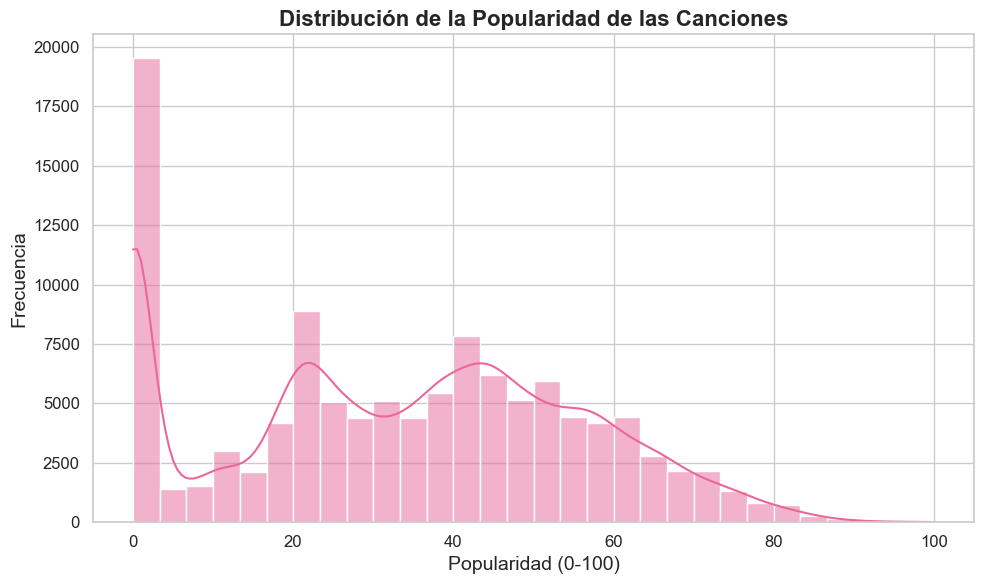

count    113549.000000
mean         33.324433
std          22.283855
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64

Porcentaje de canciones con popularidad = 0: 13.95%


In [42]:
# Se define el nombre de la variable objetivo que será utilizada en los modelos supervisados
variable_objetivo = 'popularity'

# Se verifica que la columna exista en el dataset antes de realizar el análisis
if variable_objetivo in df_final.columns:

    # Se genera un gráfico de barras de la variable objetivo
    plt.figure(figsize=(10, 6))
    sns.histplot(df_final[variable_objetivo], bins=30, kde=True, color="#e96799")
    plt.title("Distribución de la Popularidad de las Canciones", fontsize=16, fontweight="bold")
    plt.xlabel("Popularidad (0-100)")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

    print(df_final[variable_objetivo].describe())

    # Se calcula qué porcentaje de canciones tiene popularidad exactamente igual a 0
    # (esto sí es relevante: revela si hay un "exceso" de canciones nunca escuchadas)
    pct_cero = (df_final[variable_objetivo] == 0).sum() / len(df_final) * 100
    print(f"\nPorcentaje de canciones con popularidad = 0: {pct_cero:.2f}%")

# Si la variable objetivo no existe, se informa al usuario
else:
    print("La columna '{variable_objetivo}' no existe en el dataset integrado.")

### Conclusiones del Análisis de la Variable Objetivo

1. **Distribución multimodal, no una campana simple:** La variable `popularity` no sigue una distribución normal clásica, sino que presenta al menos dos "jorobas" secundarias (alrededor de 20-25 y 40-45), sugiriendo la existencia de distintos grupos o segmentos de canciones con niveles de éxito característicos, en lugar de un continuo homogéneo.

2. **Fuerte concentración en popularidad = 0 (13.95% del dataset), asociada a géneros de nicho:** Aproximadamente 1 de cada 7 canciones no registra ninguna popularidad. Al desglosar por género, se observa que estos casos se concentran en géneros tradicionales o regionales como `jazz` (681 casos), `iranian` (648), `soul` (610), `country` (587) y `latin` (585) — y no en géneros masivos como pop o hip-hop. Esto sugiere que la popularidad = 0 no es un error de datos, sino que refleja el menor alcance global de ciertos géneros musicales dentro del algoritmo de recomendación de Spotify.

3. **Implicancia para el modelamiento:** Dada la naturaleza multimodal y el exceso de ceros concentrado en géneros específicos, se evaluará si conviene abordar el problema como una **clasificación binaria** (popular vs. no popular, usando un umbral) en lugar de una regresión pura, o incluir `track_genre` como variable predictora fuerte, ya que claramente influye en el "piso" de popularidad de una canción.

4. **Rango completo utilizado:** La variable cubre todo el rango teórico (0 a 100), con una mediana de 35 y percentil 75 en 50, indicando que la mayoría de las canciones se concentra en niveles de popularidad bajos a medios, y solo una minoría alcanza valores altos (más de 75).

5. **Relevancia ética del hallazgo:** Este patrón refuerza la reflexión ética ya identificada sobre el balance artificial del dataset: si un modelo entrenado aquí se usara para decisiones reales de promoción, podría perpetuar el menor alcance de géneros culturalmente específicos (ej. `iranian`, `latin`) al aprender que estos géneros "tienden a tener popularidad baja", sin considerar que esto podría deberse a sesgos del propio algoritmo de recomendación de Spotify, no a la calidad musical.

## Análisis de variables categóricas principales

### Análisis de Variables Categóricas

Al analizar la popularidad promedio por género musical, el enfoque cambia respecto al volumen: como ya sabemos que el dataset tiene exactamente 1.000 canciones por género, esta comparación no mide "cuántas canciones hay", sino **qué tan bien le va, en promedio, a las canciones de cada género** en términos de popularidad.

Del gráfico generado se pudo extraer:

1. **Liderazgo de "pop-film" y "k-pop":** El género `pop-film` (bandas sonoras de películas con estética pop) lidera con una popularidad promedio cercana a 59, seguido de cerca por `k-pop` (~57). Esto sugiere que la asociación con contenido audiovisual masivo (películas) y fandoms globales muy activos (K-pop) impulsa fuertemente la popularidad, más allá del género musical "puro".

2. **Predominio de géneros emocionales/de mood sobre géneros técnicos:** Géneros como `chill`, `sad`, `grunge` y `emo` aparecen en el top del ranking, por delante de géneros más "genéricos" como `pop` (que aparece recién en el puesto 8, con un promedio de ~48). Esto sugiere que las etiquetas asociadas a un estado de ánimo o contexto de escucha (relajarse, tristeza) tienen un fuerte desempeño en plataformas de streaming, probablemente por su alta inclusión en playlists temáticas.

3. **Diversidad cultural en el top 15:** A diferencia de un ranking dominado únicamente por géneros angloparlantes, se observan géneros de distintas raíces culturales con buen desempeño: `indian`, `anime`, `sertanejo` (Brasil), `mandopop` (China) y `brazil`. Esto matiza el hallazgo anterior sobre géneros de nicho con popularidad = 0 (jazz, iranian, latin, soul): no todos los géneros no-mainstream tienen bajo desempeño, algunos como los mencionados logran competir con géneros tradicionalmente dominantes.

4. **Diferencia de escala moderada entre el 1° y el 15° lugar:** La distancia entre `pop-film` (~59) y `brazil` (~44, en el puesto 15) es de solo ~15 puntos, lo que indica que, dentro del top 15, no hay un género que domine de forma abismal sobre los demás — la competencia por popularidad promedio es relativamente pareja en la parte alta de la tabla.

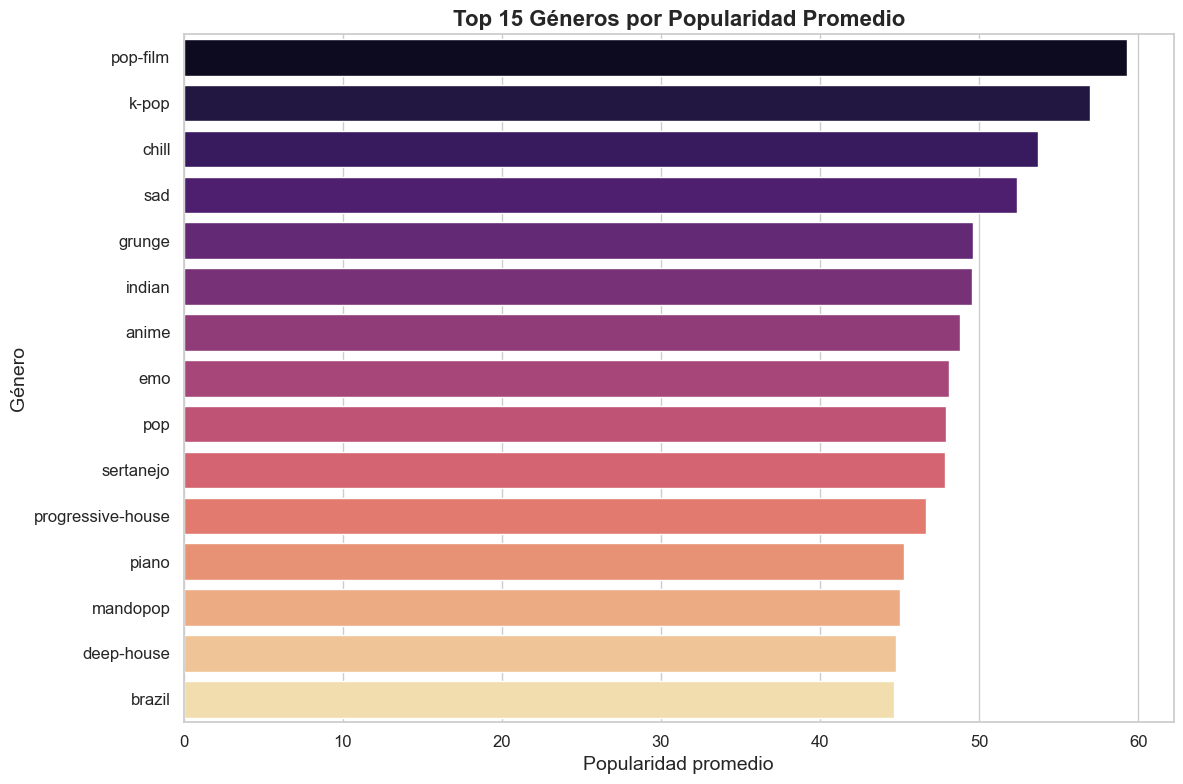

In [46]:
# Se exploran los géneros con mayor popularidad promedio
if 'track_genre' in df_final.columns:
    popularidad_por_genero = (
        df_final.groupby('track_genre')[variable_objetivo]
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(12, 8))
    sns.barplot(x=popularidad_por_genero.values, y=popularidad_por_genero.index, palette='magma')
    plt.title("Top 15 Géneros por Popularidad Promedio", fontsize=16, fontweight="bold")
    plt.xlabel("Popularidad promedio")
    plt.ylabel("Género")
    plt.tight_layout()
    plt.show()

## Análisis de distribución

### Análisis de Distribuciones Numéricas

Los histogramas revelan comportamientos muy distintos entre las variables de audio, lo que será clave al decidir si requieren transformación antes del modelamiento:

1. **Variables con distribución razonablemente simétrica:** `danceability` (media 0.57, mediana 0.58) y `valence` (media 0.47, mediana 0.46) presentan formas cercanas a una distribución normal, sin sesgos fuertes. `valence` en particular se ve casi uniforme a lo largo de todo su rango, indicando que hay canciones "tristes" y "alegres" en proporciones similares.

2. **Sesgo hacia valores altos en `energy` y `loudness`:** `energy` muestra una tendencia creciente hacia valores altos (media 0.64, mediana 0.69), y `loudness` está fuertemente concentrada entre -10 y 0 dB con una cola larga hacia la izquierda (media -8.24, mediana -7.00). Esto es coherente con la naturaleza de la música popular grabada profesionalmente, que tiende a masterizarse con volúmenes altos y consistentes.

3. **Fuerte sesgo hacia cero en `speechiness`, `acousticness` e `instrumentalness`:** Estas tres variables muestran el patrón más marcado del análisis. `instrumentalness` es el caso más extremo (media 0.16, pero mediana 0.00), lo que confirma que la gran mayoría de las canciones del dataset tienen voz (no son instrumentales), y solo un grupo reducido son temas puramente instrumentales. Lo mismo ocurre con `speechiness` (poca presencia de "habla" en la mayoría de las canciones) y, en menor medida, con `acousticness`. Estas variables probablemente requieran una transformación (ej. logarítmica) si se usan en modelos sensibles a la escala.

4. **Distribución multimodal en `tempo`:** A diferencia de las demás variables, `tempo` muestra varios picos claros (aproximadamente en 90-100, 120 y 170-200 BPM), reflejando los tempos característicos de distintos estilos musicales (baladas, pop/dance, música rápida como el punk o el drum and bass) coexistiendo en el mismo dataset.

5. **Variables excluidas de este análisis:** Se excluyeron del histograma las variables categóricas codificadas numéricamente (`key`, `mode`, `time_signature`), ya que al no ser continuas, este tipo de visualización no refleja correctamente su comportamiento — serán analizadas por separado como variables categóricas si se requiere.

En cada gráfico se calculó la media y la mediana para identificar rápidamente el grado de asimetría de cada variable.

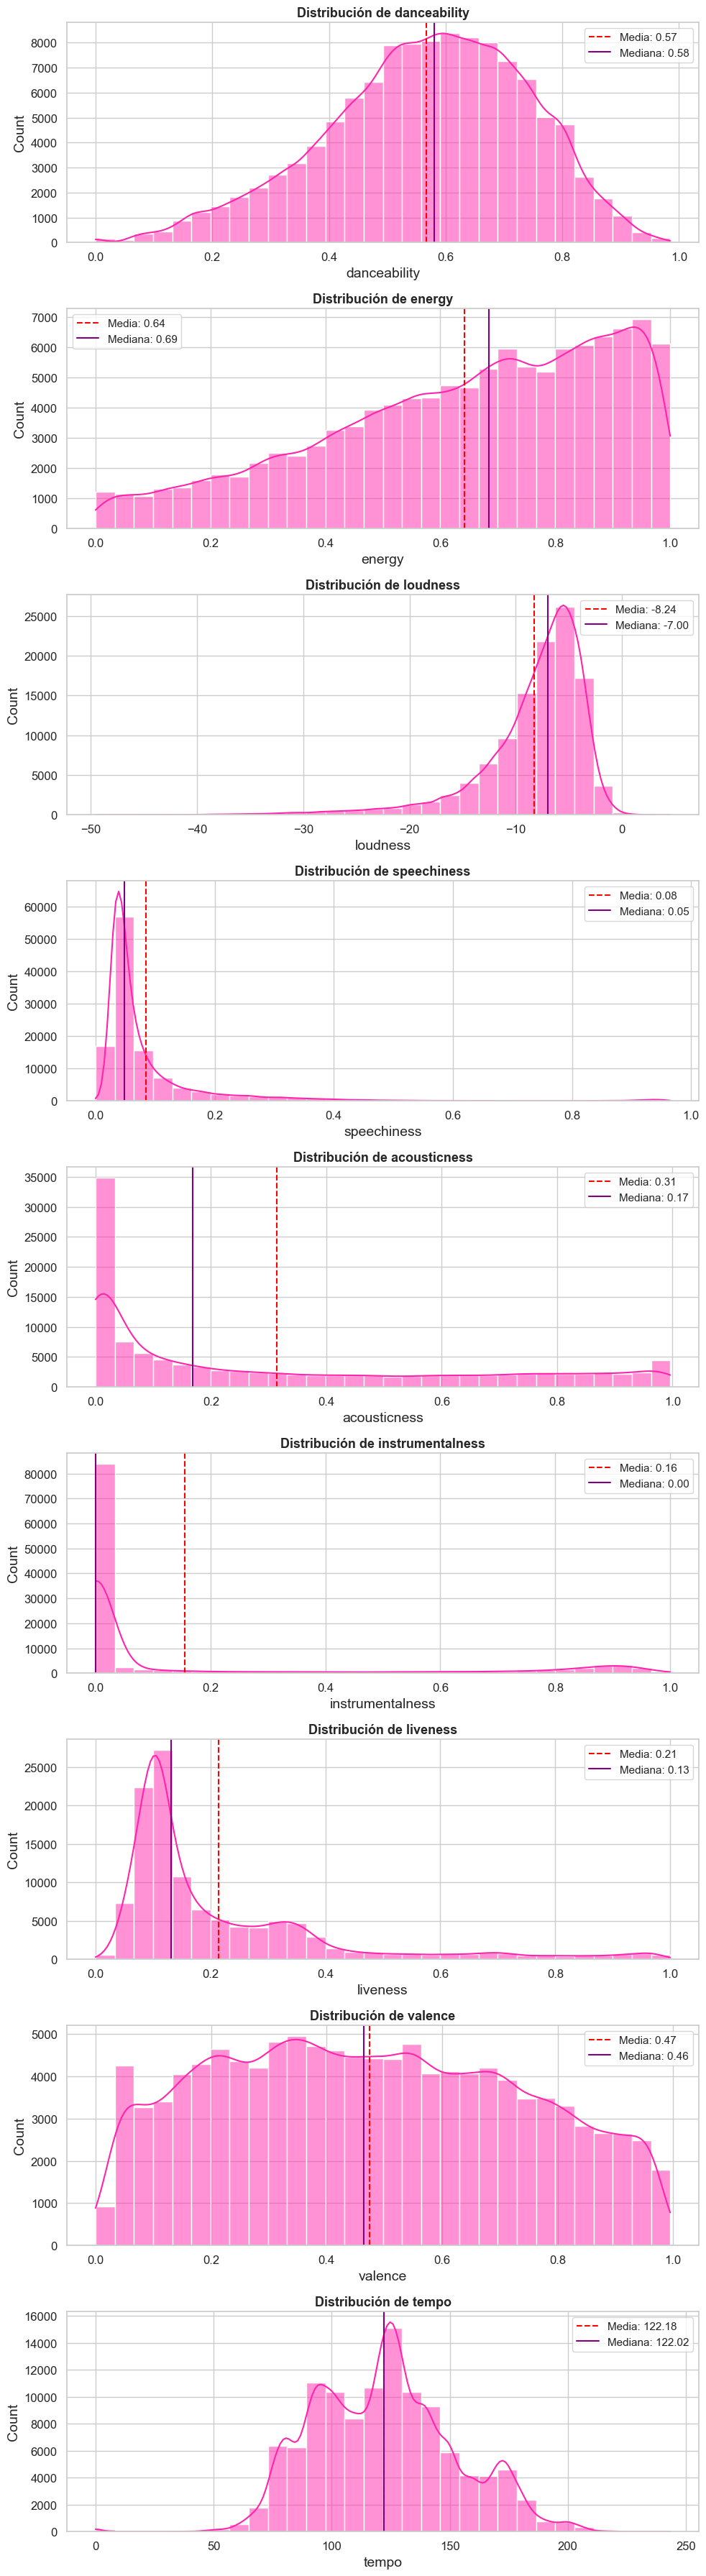

In [54]:
# Se seleccionan únicamente las variables numéricas de audio relevantes
features_audio = ['danceability', 'energy', 'loudness', 'speechiness',
                   'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
features_audio = [f for f in features_audio if f in df_final.columns]

n_features = len(features_audio)
fig, axs = plt.subplots(n_features, 1, figsize=(10, 4 * n_features))

for ax, col in zip(axs, features_audio):
    series = df_final[col].dropna()
    mean_val = series.mean()
    median_val = series.median()

    sns.histplot(series, bins=30, kde=True, color="#FF24AB", ax=ax)
    ax.axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}')
    ax.axvline(median_val, color='purple', linestyle='-', label=f'Mediana: {median_val:.2f}')
    ax.set_title(f'Distribución de {col}', fontsize=13, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

## Detección de Outliers

### Detección de Valores Atípicos (Outliers)

Al aplicar boxplots sobre las variables de audio, se observan patrones muy distintos de "outliers" según el tipo de variable, lo que sugiere que no todos deben tratarse de la misma forma:

1. **Pseudo-outliers en variables muy sesgadas hacia cero:** `speechiness`, `acousticness` e `instrumentalness` muestran una cantidad tan grande de puntos marcados como atípicos que prácticamente forman una masa continua, no casos aislados. Esto no indica errores de datos, sino que confirma lo detectado en el análisis de distribución: la mayoría de las canciones tiene valores muy bajos en estas variables, por lo que cualquier valor moderadamente alto queda estadísticamente marcado como "outlier", aunque sea perfectamente normal (ej. una canción instrumental real).

2. **Outliers genuinos y simétricos en `loudness` y `tempo`:** Estas dos variables muestran un patrón de outliers más clásico: puntos dispersos en ambos extremos, en menor cantidad. En `loudness`, destaca un grupo de canciones con valores extremadamente bajos (hasta -50 dB), probablemente pistas muy suaves o con silencios prolongados, y los ya identificados casos con valores positivos. En `tempo`, se confirma nuevamente el grupo de canciones con tempo = 0 (los 157 casos del género "sleep" ya documentados).

3. **Baja presencia de outliers en `danceability`, `energy` y `valence`:** Estas variables muestran distribuciones más balanceadas, con pocos puntos fuera de los bigotes del boxplot, coherente con lo observado en sus histogramas (formas más simétricas, sin sesgo extremo hacia 0 o 1).

**Decisión:** dado que la mayoría de los "outliers" detectados corresponden a comportamientos reales del dominio musical (canciones instrumentales, ambientales, o de bajo volumen) y no a errores de captura, no se eliminarán de forma generalizada. Se evaluará un tratamiento puntual solo si estas variables se incluyen como predictoras en un futuro modelo sensible a valores extremos.

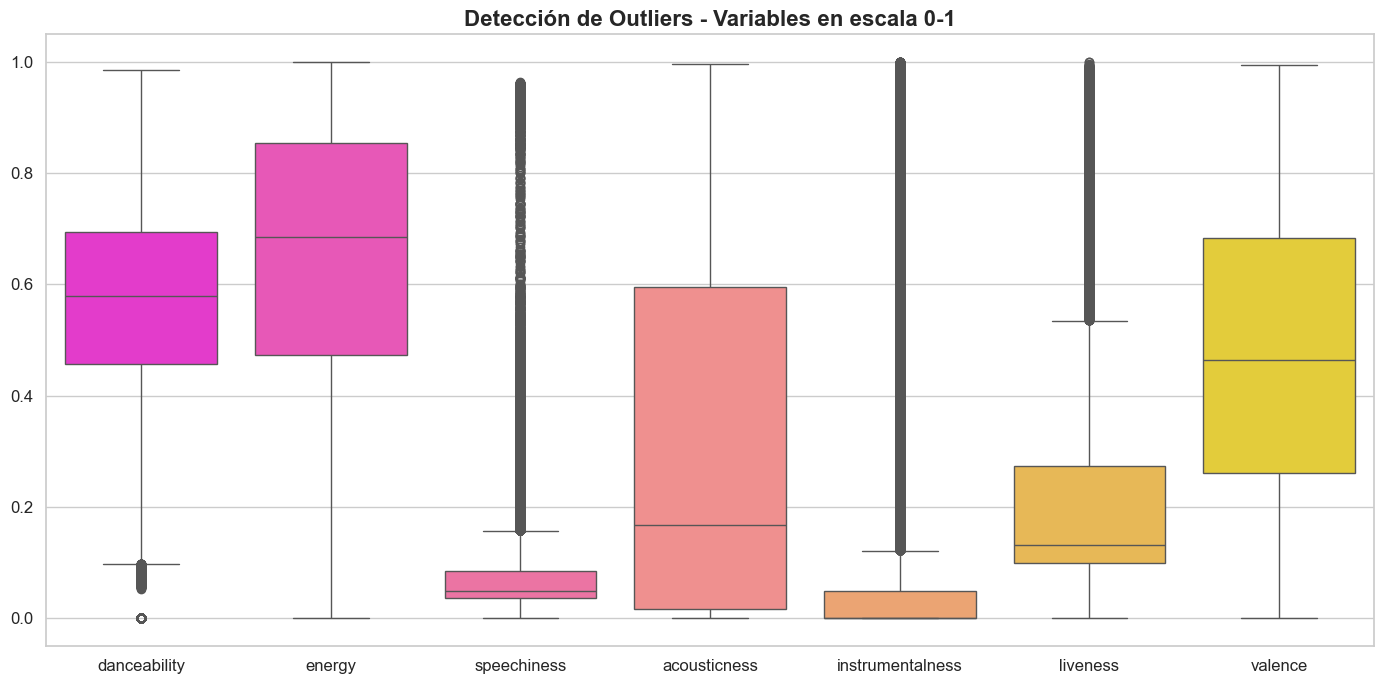

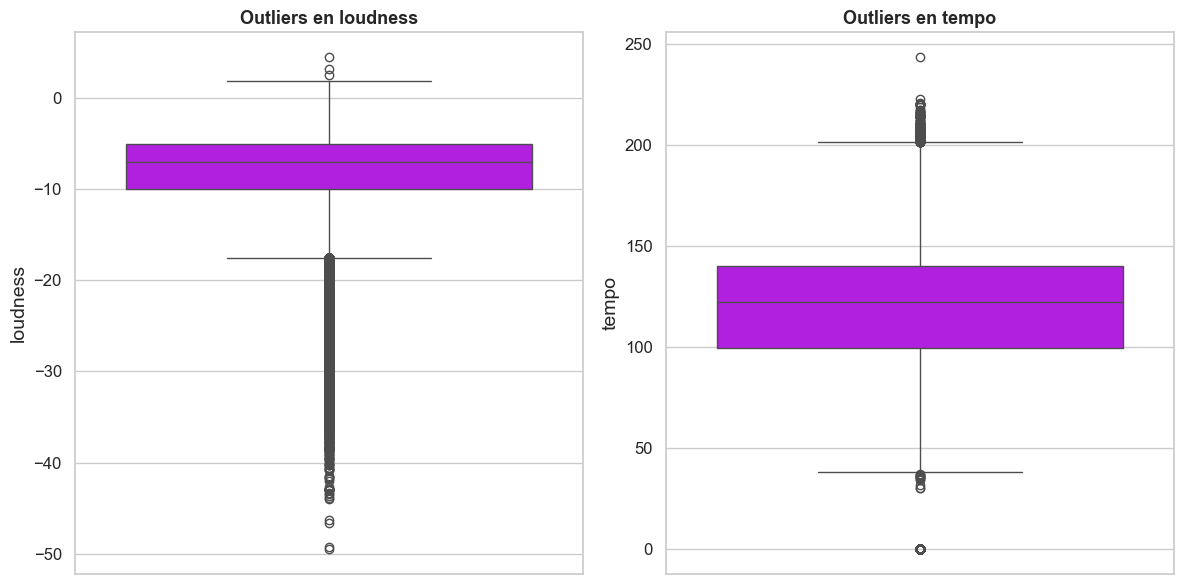

In [68]:
# Variables en escala 0-1 (comparables entre sí)
features_0_1 = ['danceability', 'energy', 'speechiness', 'acousticness',
                'instrumentalness', 'liveness', 'valence']
features_0_1 = [f for f in features_0_1 if f in df_final.columns]

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_final[features_0_1], palette="spring")
plt.title("Detección de Outliers - Variables en escala 0-1", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# Variables en otras escalas (se grafican por separado)
otras_escalas = ['loudness', 'tempo']
otras_escalas = [f for f in otras_escalas if f in df_final.columns]

fig, axs = plt.subplots(1, len(otras_escalas), figsize=(12, 6))
for ax, col in zip(axs, otras_escalas):
    sns.boxplot(y=df_final[col], ax=ax, color="#c300ff")
    ax.set_title(f'Outliers en {col}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Análisis de Correlación

### Análisis de Correlación
Se calcula la matriz de correlación de Pearson para variables numéricas

Interpretación EDA:
- Valores cercanos a 1: correlación positiva fuerte.
- Valores cercanos a -1: correlación negativa fuerte.
- Valores cercanos a 0: relación lineal débil.

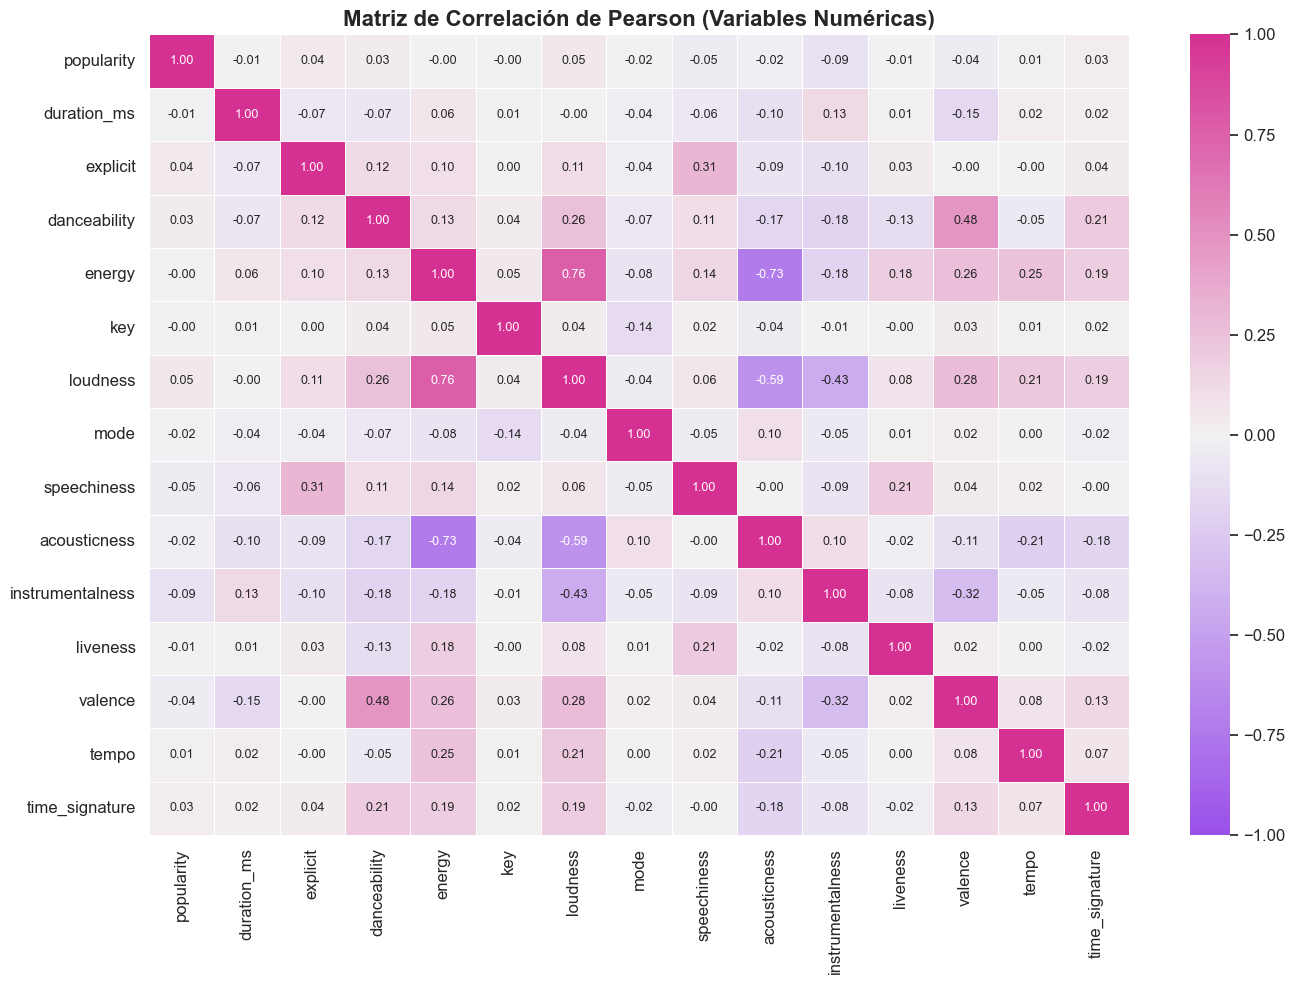


=== Correlaciones con popularity (mayor a menor) ===


loudness            0.047368
explicit            0.043938
danceability        0.034407
time_signature      0.030567
tempo               0.012187
energy             -0.002447
key                -0.004167
liveness           -0.005668
duration_ms        -0.007928
mode               -0.015009
acousticness       -0.022356
valence            -0.041097
speechiness        -0.045463
instrumentalness   -0.094718
Name: popularity, dtype: float64

In [69]:
# Se calcula la matriz de correlación utilizando únicamente variables numéricas
corr_matrix = df_final.corr(numeric_only=True)

# Se verifica que existan suficientes variables numéricas para calcular correlaciones
if corr_matrix.empty:
    print("No hay variables numéricas suficientes para calcular correlaciones.")

else:
    plt.figure(figsize=(14, 10))

    # Se crea una paleta de colores en tonos rosa y morado
    paleta_rosa_morado = sns.diverging_palette(
        280,
        340,
        s=85,
        l=50,
        as_cmap=True
    )

    sns.heatmap(
        corr_matrix,
        cmap=paleta_rosa_morado,
        center=0,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 9},
        linewidths=0.5,
        vmin=-1,
        vmax=1
    )
    plt.title("Matriz de Correlación de Pearson (Variables Numéricas)", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

    if variable_objetivo in corr_matrix.columns:
        correlaciones_popularidad = (
            corr_matrix[variable_objetivo]
            .drop(variable_objetivo)
            .sort_values(ascending=False)
        )
        print("\n=== Correlaciones con popularity (mayor a menor) ===")
        display(correlaciones_popularidad)

### Interpretación de la Matriz de Correlación

El análisis de correlación de Pearson permite identificar cómo se relacionan linealmente las variables del dataset de Spotify. A partir del mapa de calor y el listado de correlaciones con la variable objetivo, se extraen las siguientes conclusiones:

**1. Hallazgo principal: ninguna variable de audio predice `popularity` por sí sola**

A diferencia de lo esperado, ninguna característica de audio muestra una correlación lineal relevante con la popularidad. La correlación más fuerte es apenas `instrumentalness` (-0.09), seguida de `loudness` (0.05) y `explicit` (0.04) — todas prácticamente insignificantes en términos estadísticos. **Implicancia para el modelo:** esto sugiere que la popularidad de una canción no depende linealmente de sus características sonoras individuales, sino probablemente de factores externos no capturados en este dataset (marketing, presencia del artista, playlists editoriales, momento de lanzamiento, etc.), y/o de relaciones no lineales o combinadas entre variables (ej. interacciones), que un modelo lineal simple no podría capturar. Un modelo de árboles o ensamble podría rendir mejor que una regresión lineal simple.

**2. Colinealidad fuerte entre `energy`, `loudness` y `acousticness`**

Se observa una relación muy marcada entre estas tres variables:
- **`energy` con `loudness` (0.76):** canciones más energéticas tienden a estar masterizadas con mayor volumen.
- **`energy` con `acousticness` (-0.73)** y **`loudness` con `acousticness` (-0.59):** relación inversa fuerte — canciones acústicas tienden a ser menos energéticas y más suaves.

**Implicancia para el modelo:** este es un caso claro de *multicolinealidad*. Si se usan estas tres variables juntas en un modelo lineal, aportarían información redundante y podrían distorsionar la estabilidad de los coeficientes. Se recomienda evaluar la eliminación de una de ellas (por ejemplo, conservar `energy` y `acousticness`, descartando `loudness` por ser la más redundante con ambas) o aplicar una técnica de reducción de dimensionalidad si se usan todas.

**3. Relación moderada entre estado de ánimo y ritmo**

- **`danceability` con `valence` (0.48):** las canciones más "bailables" tienden a transmitir mayor positividad emocional, una relación intuitiva (música alegre suele ser también más rítmica).
- **`instrumentalness` con `valence` (-0.32):** las canciones instrumentales tienden a transmitir menor positividad que las canciones con voz.

**4. Relación entre contenido explícito y presencia de voz hablada**

- **`explicit` con `speechiness` (0.31):** las canciones marcadas como contenido explícito presentan mayor proporción de palabras habladas, coherente con géneros como el rap/hip-hop, donde el contenido explícito y el estilo "hablado" suelen coexistir.

**5. Variables prácticamente independientes entre sí**

Variables como `key`, `time_signature` y `duration_ms` muestran correlaciones cercanas a 0 con casi todas las demás variables, incluyendo `popularity`. Esto sugiere que aportan poca información lineal al problema y podrían tener bajo peso en un modelo predictivo basado en correlaciones simples.

## Preparación de Datos para el Modelamiento

Con base en los hallazgos del EDA, se preparan los datos para que puedan ser utilizados en un futuro proceso de modelamiento.

In [70]:
# 1. Se excluyen columnas identificatorias y la variable objetivo del set de predictores
# (track_id, track_name, artists, album_name no aportan valor predictivo directo)
X = df_final.drop(columns=[variable_objetivo, 'track_id', 'track_name', 'artists', 'album_name'], errors='ignore')
y = df_final[variable_objetivo]

# 2. Se imputa el valor de tempo=0 con la mediana de tempo del mismo género,
# ya que un tempo de 0 no es musicalmente real (ver hallazgo en sección de outliers)
mediana_por_genero = df_final.groupby('track_genre')['tempo'].transform(
    lambda serie: serie.replace(0, serie.median())
)
X['tempo'] = mediana_por_genero

# 3. Codificación de la variable categórica track_genre (114 categorías)
# Nota: esto generará ~113 columnas nuevas (one-hot encoding), aumentando
# significativamente la dimensionalidad del dataset
X = pd.get_dummies(X, columns=['track_genre'], drop_first=True)

# 4. División en conjuntos de entrenamiento y prueba (ANTES de escalar, para evitar fuga de datos)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño set de entrenamiento: {X_train.shape}")
print(f"Tamaño set de prueba: {X_test.shape}")

# 5. Escalamiento de variables numéricas de audio
# Se ajusta (fit) SOLO con datos de entrenamiento, y se aplica (transform) a ambos conjuntos
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
columnas_a_escalar = [f for f in features_audio if f in X_train.columns]

X_train[columnas_a_escalar] = scaler.fit_transform(X_train[columnas_a_escalar])
X_test[columnas_a_escalar] = scaler.transform(X_test[columnas_a_escalar])

print("\nPreparación de datos completada.")

Tamaño set de entrenamiento: (90839, 127)
Tamaño set de prueba: (22710, 127)

Preparación de datos completada.


### Conclusiones de la Preparación de Datos

1. **Exclusión de variables identificatorias:** Se descartaron `track_id`, `track_name`, `artists` y `album_name` del set de predictores, ya que son identificadores de alta cardinalidad sin valor predictivo directo (confirmado en el análisis de estadísticas descriptivas: `track_id` tiene 89.740 valores únicos, `artists` 31.437).

2. **Imputación de `tempo = 0` por mediana de género:** Los 157 casos con tempo no detectado (concentrados en el género `sleep`) fueron reemplazados por la mediana de tempo de su propio género, en lugar de usar la mediana global. Esto preserva la coherencia musical de cada género en lugar de introducir un valor "genérico" que no refleja el contexto real de esas canciones.

3. **Codificación de `track_genre` mediante one-hot encoding:** Esta transformación incrementó significativamente la dimensionalidad del dataset, de 16 columnas predictoras originales a **127 columnas finales**, producto casi en su totalidad de las 113 categorías de género codificadas como variables binarias. Esta alta dimensionalidad deberá considerarse al elegir el algoritmo de modelamiento (algunos modelos, como los basados en árboles, manejan mejor este escenario que los modelos lineales).

4. **División train/test antes del escalamiento:** Se dividió el dataset en 80% entrenamiento (90.839 filas) y 20% prueba (22.710 filas) **antes** de aplicar el escalamiento de variables numéricas, ajustando el `StandardScaler` únicamente con los datos de entrenamiento. Esto evita la fuga de datos (*data leakage*): si se hubiera escalado con el dataset completo, el modelo habría tenido acceso indirecto a información estadística del conjunto de prueba antes de ser evaluado, invalidando la evaluación de su capacidad de generalización.

5. **Variables de audio escaladas:** `danceability`, `energy`, `loudness`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence` y `tempo` fueron estandarizadas (media 0, desviación estándar 1), necesario dado que estas variables presentan escalas y rangos muy distintos entre sí (ej. `tempo` en decenas/cientos vs. `danceability` en 0-1), lo cual podría sesgar a modelos sensibles a la magnitud de las variables.

## Consideraciones Éticas y de Sesgos
A lo largo del análisis exploratorio se identificaron varios elementos que ameritan una reflexión ética sobre el uso de este dataset y sus implicancias si se utilizara para decisiones reales de negocio.

### 1. Sesgo de representación: balance artificial por género

El dataset contiene exactamente 1.000 canciones para cada uno de los 114 géneros musicales, sin excepción. Esto **no refleja la distribución real de géneros en Spotify**, donde géneros mainstream como el pop o el hip-hop concentran una proporción mucho mayor de streams y catálogo que géneros de nicho. Un modelo entrenado bajo este balance artificial podría aprender relaciones que no se sostienen en el mundo real, donde la disponibilidad de datos por género es muy desigual.

### 2. Sesgo cultural en la variable de popularidad

Se detectó que el 13.95% de las canciones tiene `popularity = 0`, y que estos casos se concentran fuertemente en géneros culturalmente específicos o tradicionales (`jazz`, `iranian`, `soul`, `latin`, `romance`), mientras que géneros como `pop-film` y `k-pop` lideran el promedio de popularidad. Esto podría reflejar un sesgo real del algoritmo de recomendación de Spotify —que tiende a favorecer ciertos mercados y estéticas musicales (principalmente angloparlantes)—, más que una diferencia objetiva de calidad musical entre géneros.

### 3. Riesgo de retroalimentación (feedback loop)

Si una discográfica o plataforma usara un modelo entrenado con este dataset para decidir en qué canciones invertir en promoción, existe el riesgo de que el modelo **refuerce el sesgo existente**: al predecir que las canciones de ciertos géneros "tienden a ser menos populares", se les asignaría menos promoción, lo que a su vez reduciría aún más su alcance real, confirmando la predicción de forma artificial (profecía autocumplida). Esto podría perjudicar de forma sistemática a artistas de géneros ya marginados en la plataforma.

### 4. Privacidad de los datos

Este dataset no contiene información personal de usuarios (no incluye historiales de escucha, ubicación, edad ni identidad de oyentes), por lo que el riesgo de privacidad individual es bajo. La responsabilidad ética se concentra, en este caso, en el impacto sobre artistas y géneros musicales, no sobre usuarios finales.

### 5. Recomendación de mitigación

Si este modelo se implementara en un contexto real, se recomienda: (a) no usar la predicción de popularidad como único criterio de inversión en promoción, complementándola con criterios cualitativos y de diversidad cultural; (b) monitorear si el modelo perpetúa sistemáticamente bajas predicciones para ciertos géneros o mercados, y (c) evitar entrenar el modelo exclusivamente con este dataset balanceado artificialmente si se busca una aplicación en el mundo real, dado que no representa la distribución genuina del catálogo de la plataforma.

### 6. Impacto emocional y bienestar del oyente

Un hallazgo relevante del análisis es que géneros o etiquetas asociadas a estados de ánimo específicos —como `chill` y `sad`— se ubican entre los de mayor popularidad promedio, por encima incluso de géneros musicales "tradicionales" como el pop. Esto sugiere que las plataformas de streaming, y los algoritmos que optimizan popularidad y "engagement", no solo recomiendan música por afinidad sonora, sino que **capitalizan estados emocionales del oyente**, incluyendo el ánimo bajo o la tristeza (ej. playlists como "Sad Songs" o "Heartbreak").

Esto abre una pregunta ética relevante para cualquier modelo de negocio construido sobre este tipo de datos: **¿es responsable optimizar un algoritmo para maximizar el consumo de contenido asociado a estados emocionales negativos, si esto genera mayor "popularidad" o tiempo de escucha, pero no necesariamente beneficia el bienestar del oyente?** Un modelo que aprenda que la música "triste" genera alta popularidad podría, sin intención maliciosa, incentivar a una plataforma a promover más este tipo de contenido en usuarios vulnerables emocionalmente, priorizando métricas de negocio (tiempo de escucha, popularidad) por sobre el bienestar del usuario.

**Recomendación de mitigación:** si se implementara un sistema de recomendación basado en este tipo de modelo, se sugiere incorporar salvaguardas que eviten la sobreexposición sostenida a contenido de valencia emocional negativa (`valence` baja) en un mismo oyente, y priorizar la diversidad emocional del contenido recomendado por sobre la pura maximización de métricas de popularidad o tiempo de escucha.

In [ ]:
# Evidencia cuantitativa para respaldar la discusión ética:
# distribución de la cantidad de canciones por género (para detectar sobre-representación)
if 'track_genre' in df_final.columns:
    conteo_generos = df_final['track_genre'].value_counts()
    print(f"Número de géneros distintos: {conteo_generos.shape[0]}")
    print(f"Género con más canciones: {conteo_generos.idxmax()} ({conteo_generos.max()} canciones)")
    print(f"Género con menos canciones: {conteo_generos.idxmin()} ({conteo_generos.min()} canciones)")
    print(f"Desviación estándar entre géneros: {conteo_generos.std():.2f}")

Número de géneros distintos: 114
Género con más canciones: acoustic (1000 canciones)
Género con menos canciones: romance (904 canciones)
Desviación estándar entre géneros: 11.84


: 

## Conclusiones del Análisis Exploratorio

### 1. Calidad y limpieza de los datos

El dataset original contenía 114.000 filas, prácticamente sin valores nulos (un único registro corrupto sin metadata y con `duration_ms = 0`, que fue eliminado). Sin embargo, al remover la columna de índice residual `Unnamed: 0`, se reveló que 450 filas eran duplicados exactos, los cuales también fueron eliminados. Adicionalmente, se identificaron 24.259 registros con `track_id` repetido, correspondientes a canciones legítimamente catalogadas en múltiples géneros — estos **no** fueron eliminados, ya que representan información válida. El dataset final quedó compuesto por **113.549 filas** y 21 columnas originales.

### 2. Hallazgos clave del EDA

- **La popularidad no depende linealmente de las características de audio:** ninguna variable individual (danceability, energy, acousticness, etc.) mostró una correlación relevante con `popularity` (todas por debajo de 0.10). Esto sugiere que factores externos no capturados en el dataset (marketing, algoritmo de recomendación, presencia del artista) influyen más que el sonido en sí.
- **Fuerte multicolinealidad entre variables de audio:** `energy`, `loudness` y `acousticness` están altamente correlacionadas entre sí, lo que deberá considerarse en cualquier modelo lineal futuro.
- **13.95% de las canciones tienen popularidad = 0**, concentradas en géneros tradicionales o de nicho (jazz, iranian, soul, latin), mientras que géneros como `pop-film` y `k-pop` lideran el promedio de popularidad.
- **Valores atípicos con explicación de dominio:** tempo y compás en 0 (música ambiental/sleep), duración de 87 minutos (mix de DJ) y loudness positivo (masterización agresiva) resultaron ser características reales del dominio musical, no errores de datos.

### 3. Decisiones de preparación de datos

Se excluyeron las variables identificatorias de alta cardinalidad (`track_id`, `track_name`, `artists`, `album_name`), se imputó el `tempo = 0` con la mediana del género correspondiente, se codificó `track_genre` mediante one-hot encoding (generando 127 columnas finales), y se dividió el dataset en conjuntos de entrenamiento (80%) y prueba (20%) **antes** de escalar las variables numéricas, evitando así la fuga de datos.

### 4. Reflexión ética

El hallazgo más relevante fue que el dataset está **artificialmente balanceado por género** (114 géneros con distribución casi idéntica, desviación estándar de solo 11.84 canciones), lo cual no refleja la distribución real de consumo musical en Spotify. Esto, combinado con la concentración de baja popularidad en géneros culturalmente específicos, plantea un riesgo real de que un modelo entrenado con estos datos perpetúe sesgos existentes en la plataforma si se usara para decisiones reales de promoción musical (efecto de retroalimentación). Adicionalmente, se identificó que géneros asociados a estados emocionales (`chill`, `sad`) figuran entre los más populares, lo que abre una discusión sobre la responsabilidad de optimizar algoritmos de recomendación en torno a estados emocionales del oyente, más allá de la pura maximización de métricas de negocio.

### 5. Próximos pasos sugeridos

Para una futura etapa de modelamiento, se recomienda evaluar modelos no lineales (ej. Random Forest, Gradient Boosting) dado que las relaciones lineales resultaron débiles, e incorporar el género musical como variable predictora relevante, considerando al mismo tiempo las salvaguardas éticas discutidas para evitar perpetuar sesgos de representación.